In [30]:
'''
HCAHPS Regional Performance Audit: BigQuery to Python Pipeline
Project Overview
This notebook serves as the Visualization & Statistical Analysis layer of the Hospital Consumer Assessment of Healthcare Providers and Systems (HCAHPS) project. 
    The goal is to identify operational categories with the highest regional performance variation across 7 states.

Data Pipeline & Connectivity
Instead of using static CSV files, this analysis connects directly to a Google BigQuery data warehouse to ensure data integrity and scalability.

Source: healthcareanalysis-479317.new_analysis.new_analysis_view

Infrastructure: Authenticated via google-cloud-bigquery using service account credentials.

Logic Layer: The data pulled is a pre-transformed SQL View that includes:

Regex-parsed footnotes to filter out suppressed data.

Standardized Measure Mapping for human-readable category grouping.

Reliability Logic ensuring only the high-integrity cohort of 28,499 records is analyzed.

Primary Objective
To visualize the "Care Gap"—the statistical disparity between standardized clinical communication (Nurses/Doctors) and volatile environmental factors (Quietness/Cleanliness).
'''

In [1]:
# These libraries were needed to execute the next blocks of code

#pip install google-cloud-bigquery
#!pip install db-dtypes
#!pip install google-cloud-bigquery-storage


In [8]:
from google.cloud import bigquery
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import db_dtypes

# 1. Initialize the BigQuery client
client = bigquery.Client(project="healthcareanalysis-479317")


In [9]:
# 2. Query your view for ONLY reliable data
# This handles the "count" issue by filtering at the source
query = """
SELECT state, measure_group, score
FROM `healthcareanalysis-479317.new_analysis.new_analysis_view`
WHERE is_reliable = 1 
  AND measure_group != 'Other'
"""

In [10]:
# 3. Load into a Pandas DataFrame
df_clean = client.query(query).to_dataframe()

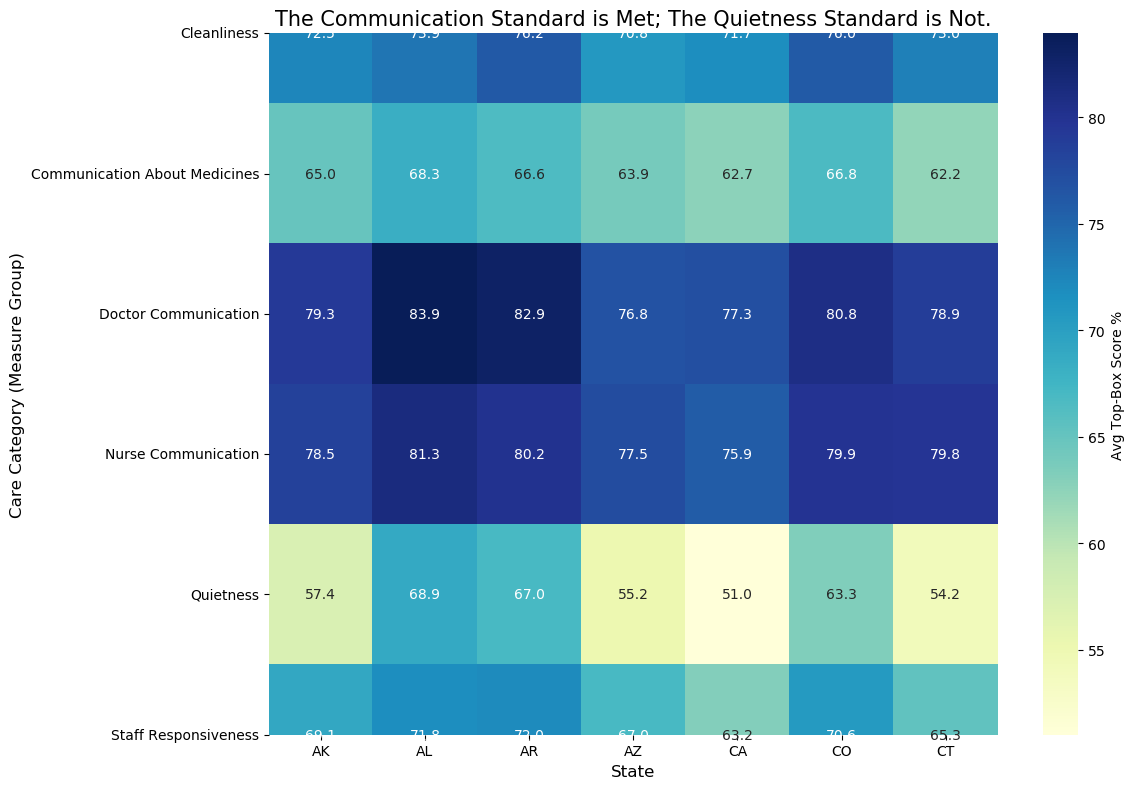

In [11]:
#Building the "Volatility" Heatmap

# Create a pivot table for the Heatmap
pivot_df = df_clean.groupby(['measure_group', 'state'])['score'].mean().unstack()

# Plotting
plt.figure(figsize=(12, 8))
plt.subplots_adjust(top=0.5, bottom=0.2)
sns.heatmap(pivot_df, annot=True, cmap="YlGnBu", fmt=".1f", cbar_kws={'label': 'Avg Top-Box Score %'})

plt.title('The Communication Standard is Met; The Quietness Standard is Not.', fontsize=15)
plt.ylabel('Care Category (Measure Group)', fontsize=12)
plt.xlabel('State', fontsize=12)

plt.tight_layout()
plt.show()

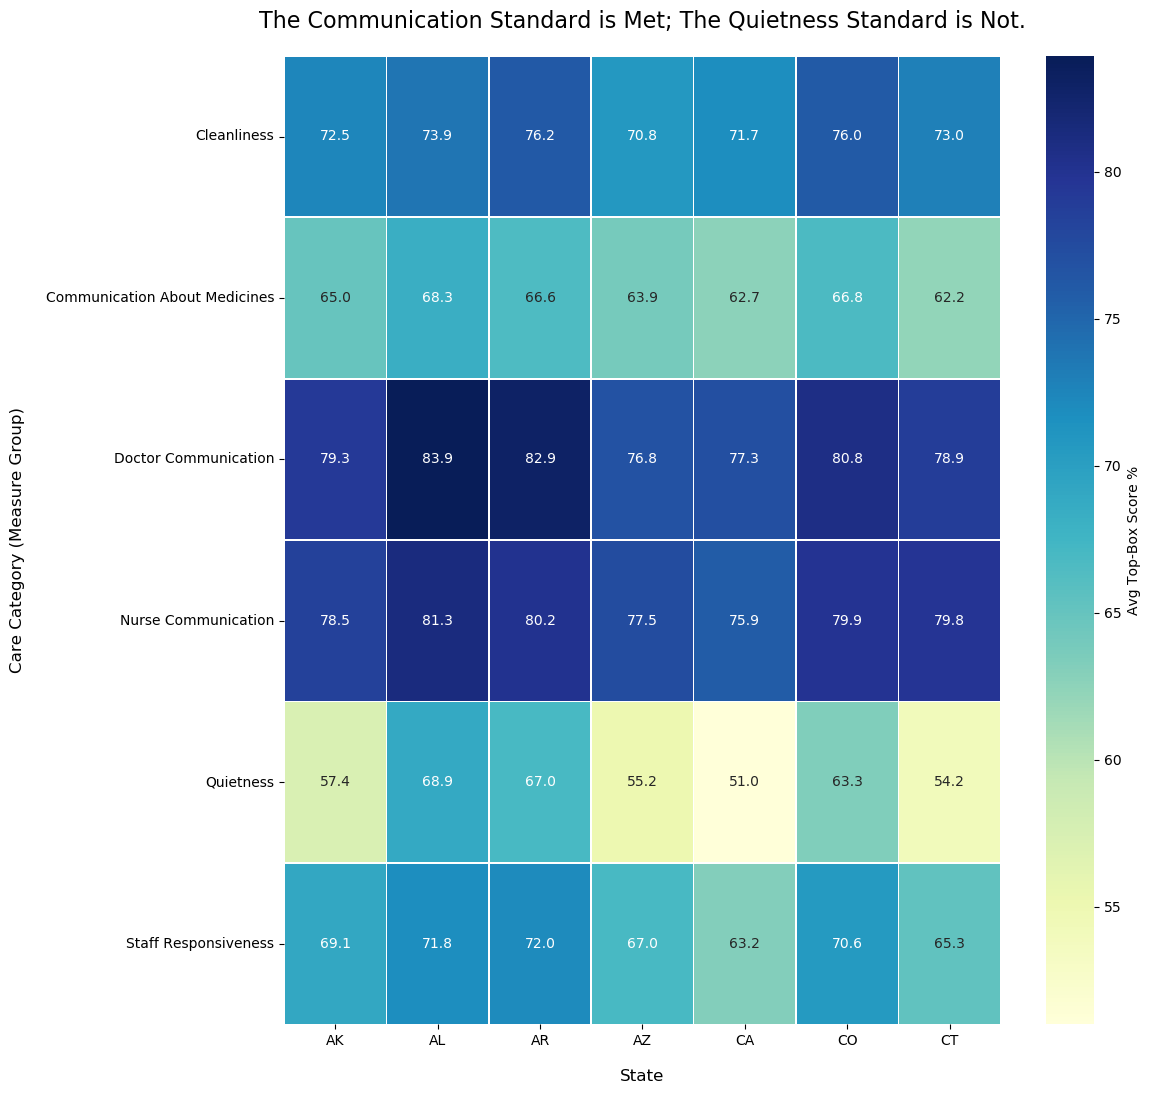

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set a larger figure size with a taller height
plt.figure(figsize=(12, 12)) 

# 2. Use 'ax' to get direct control over the axes
ax = sns.heatmap(
    pivot_df, 
    annot=True, 
    cmap="YlGnBu", 
    fmt=".1f",
    linewidths=.5, # Adds a small gap between blocks to prevent bleeding
    cbar_kws={'label': 'Avg Top-Box Score %'}
)

# 3. MANUAL FIX: Adjust the y-axis limits
# This prevents the top and bottom rows from being "chopped" in half
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)

# 4. Final Formatting
plt.title('The Communication Standard is Met; The Quietness Standard is Not.', fontsize=16, pad=20)
plt.ylabel('Care Category (Measure Group)', fontsize=12, labelpad=15)
plt.xlabel('State', fontsize=12, labelpad=15)

# 5. Force the layout to respect the labels
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 

plt.show()